## 1. Setup, file paths and visual theme

# Traffic-Light Mode Energy Comparison

Compare two BEB simulation outputs for the same route and same service day:

- Traffic lights ON: `traffic_signals.enabled=true`
- Traffic lights OFF: `traffic_signals.enabled=false`

The notebook checks that the two files are aligned, then plots the change in route-day energy, trip energy, segment intensity, and duty-level SoC reserve. The visual theme follows the route 208 analysis notebook palette.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import PercentFormatter
from pathlib import Path
import seaborn as sns
from IPython.display import display

# -----------------------------------------------------------------------------
# Input files
# -----------------------------------------------------------------------------
# Replace WITHOUT_SIGNALS_CSV with the matching run generated with traffic lights OFF.
# The two CSVs should be the same route/date/service selection; only signal mode changes.
WITH_SIGNALS_CSV = Path(r"../data/processed/route_208_trips_2025_07_09.csv")
WITHOUT_SIGNALS_CSV = Path(r"../data/processed/route_208_trips_2025_07_09_no_traffic.csv")

# Keep True for real analysis. For layout testing only, set False and point both
# paths to any compatible sample CSV.
REQUIRE_TWO_FILES = True

SAVE_FIGURES = False
FIG_DIR = Path("../figures/traffic_light_comparison")

# Palette copied from the route 208 analysis notebook.
INK   = "#1f2433"
OFF   = "#2a9d8f"   # signals off
ON    = "#e76f51"   # signals on
ACC   = "#3d5a80"
ACC2  = "#ee9b00"
REGEN = "#52b788"
GRID  = "#dde1e7"
MUTED = "#6b7280"
SEQ   = "mako"
DIV   = "vlag"

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK, "ytick.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 10,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False,
})

def titled(ax, title, subtitle=None):
    ax.set_title(title, loc="left")
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes,
                fontsize=9.5, color=MUTED, ha="left", va="bottom")
    return ax

def savefig(fig, name):
    if SAVE_FIGURES:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")

def delta_label(delta, base):
    if pd.isna(delta) or pd.isna(base) or abs(base) < 1e-12:
        return "n/a"
    return f"{delta:+.2f} ({delta/base*100:+.1f}%)"


## 2. Load, normalize and check pairing

In [37]:
def gtfs_seconds(value):
    """GTFS times may exceed 24:00:00; return seconds from service-day midnight."""
    if pd.isna(value):
        return np.nan
    parts = str(value).split(":")
    if len(parts) < 2:
        return np.nan
    h = int(float(parts[0])); m = int(float(parts[1])); s = int(float(parts[2])) if len(parts) > 2 else 0
    return h * 3600 + m * 60 + s

def normalize_energy_schema(df, mode):
    df = df.copy()
    df["mode"] = mode
    df["dist_km"] = df["length_m"] / 1000.0
    df["speed_kmh"] = np.where(df["run_time_s"] > 0, df["length_m"] / df["run_time_s"] * 3.6, np.nan)
    df["dir_label"] = df["direction_id"].map({0: "Outbound", 1: "Inbound"}).fillna(df["direction_id"].astype(str))
    df["dep_s"] = df["trip_start_time"].map(gtfs_seconds)
    df["dep_hour"] = (df["dep_s"] // 3600).astype("Int64")
    df["is_regen"] = df["net_battery_energy_kWh"] < 0
    if "n_signals" not in df.columns:
        df["n_signals"] = 0
    if "signal_source" not in df.columns:
        df["signal_source"] = "none"
    return df

def require_file(path, label):
    if not Path(path).is_file():
        msg = f"{label} CSV not found: {path}"
        if REQUIRE_TWO_FILES:
            raise FileNotFoundError(msg + "\nSet the path in the first code cell, then rerun.")
        print("WARNING:", msg)
    return Path(path)

require_file(WITH_SIGNALS_CSV, "WITH_SIGNALS_CSV")
require_file(WITHOUT_SIGNALS_CSV, "WITHOUT_SIGNALS_CSV")

on = normalize_energy_schema(pd.read_csv(WITH_SIGNALS_CSV), "Signals on")
off = normalize_energy_schema(pd.read_csv(WITHOUT_SIGNALS_CSV), "Signals off")
all_df = pd.concat([off, on], ignore_index=True)

checks = pd.Series({
    "route_short_name": off["route_short_name"].iloc[0] == on["route_short_name"].iloc[0],
    "simulation_date": off["simulation_date"].iloc[0] == on["simulation_date"].iloc[0],
    "trip_count": off["trip_id"].nunique() == on["trip_id"].nunique(),
    "segment_rows": len(off) == len(on),
    "segment_keys": set(zip(off.trip_id, off.segment)) == set(zip(on.trip_id, on.segment)),
})
print("Pairing checks")
print(checks.to_string())
if not checks.all():
    print("\nWARNING: at least one pairing check failed. Delta plots use inner joins only.")

route_name = f"{on.route_short_name.iloc[0]} - {on.route_long_name.iloc[0]}"
service_date = str(on.simulation_date.iloc[0])
print(f"\nLoaded route {route_name} | date {service_date}")
print(f"Rows: off={len(off):,}, on={len(on):,} | trips: off={off.trip_id.nunique():,}, on={on.trip_id.nunique():,}")


Pairing checks
route_short_name    True
simulation_date     True
trip_count          True
segment_rows        True
segment_keys        True

Loaded route 208 - Lotabeg - Bishopstown - Curraheen | date 2025-07-09
Rows: off=7,561, on=7,561 | trips: off=206, on=206


## 3. Build paired segment, trip and duty tables

In [38]:
def make_trip_table(df):
    out = (df.groupby(["mode", "trip_id"], observed=True)
        .agg(route_short_name=("route_short_name", "first"),
             route_long_name=("route_long_name", "first"),
             simulation_date=("simulation_date", "first"),
             duty_id=("duty_id", "first"),
             duty_trip_index=("duty_trip_index", "first"),
             direction_id=("direction_id", "first"),
             dir_label=("dir_label", "first"),
             dep_s=("dep_s", "first"), dep_hour=("dep_hour", "first"),
             trip_start_time=("trip_start_time", "first"),
             segments=("segment", "count"),
             dist_km=("dist_km", "sum"),
             run_min=("run_time_s", lambda s: s.sum()/60),
             dwell_min=("dwell_s", lambda s: s.sum()/60),
             n_signals=("n_signals", "sum"),
             pax_mean=("passengers", "mean"),
             net_kWh=("net_battery_energy_kWh", "sum"),
             gross_kWh=("gross_consumed_kWh", "sum"),
             regen_kWh=("regen_recovered_kWh", "sum"),
             aux_kWh=("aux_energy_kWh", "sum"),
             soc0=("trip_start_soc_%", "first"),
             soc1=("trip_end_soc_%", "first"))
        .reset_index())
    out["kWh_per_km"] = out["net_kWh"] / out["dist_km"]
    out["duration_min"] = out["run_min"] + out["dwell_min"]
    return out

def make_duty_table(df):
    out = (df.sort_values(["duty_id", "duty_trip_index", "segment"])
        .groupby(["mode", "duty_id"], observed=True)
        .agg(trips=("trip_id", "nunique"), dist_km=("dist_km", "sum"),
             net_kWh=("net_battery_energy_kWh", "sum"), n_signals=("n_signals", "sum"),
             start_time=("trip_start_time", "first"), soc_start=("SoC_start_%", "first"),
             soc_end=("SoC_end_%", "last"), soc_min=("SoC_end_%", "min"))
        .reset_index())
    out["kWh_per_km"] = out["net_kWh"] / out["dist_km"]
    return out

trips = make_trip_table(all_df)
duties = make_duty_table(all_df)

seg_cols = ["trip_id", "segment", "direction_id", "dir_label", "dep_s", "dep_hour", "dist_km", "length_m", "grade_%",
            "passengers", "n_signals", "net_battery_energy_kWh", "gross_consumed_kWh", "regen_recovered_kWh",
            "aux_energy_kWh", "net_battery_kWh_per_km", "SoC_start_%", "SoC_end_%"]
seg_pair = off[seg_cols].merge(on[seg_cols], on=["trip_id", "segment"], suffixes=("_off", "_on"), how="inner")
for col in ["net_battery_energy_kWh", "net_battery_kWh_per_km", "gross_consumed_kWh", "regen_recovered_kWh", "aux_energy_kWh", "n_signals"]:
    seg_pair[f"delta_{col}"] = seg_pair[f"{col}_on"] - seg_pair[f"{col}_off"]
seg_pair["delta_pct_energy"] = seg_pair["delta_net_battery_energy_kWh"] / seg_pair["net_battery_energy_kWh_off"].replace(0, np.nan) * 100

trip_pair = trips[trips["mode"] == "Signals off"].merge(trips[trips["mode"] == "Signals on"], on="trip_id", suffixes=("_off", "_on"), how="inner")
for col in ["net_kWh", "kWh_per_km", "gross_kWh", "regen_kWh", "aux_kWh", "n_signals", "soc1"]:
    trip_pair[f"delta_{col}"] = trip_pair[f"{col}_on"] - trip_pair[f"{col}_off"]
trip_pair["delta_pct_energy"] = trip_pair["delta_net_kWh"] / trip_pair["net_kWh_off"].replace(0, np.nan) * 100

duty_pair = duties[duties["mode"] == "Signals off"].merge(duties[duties["mode"] == "Signals on"], on="duty_id", suffixes=("_off", "_on"), how="inner")
for col in ["net_kWh", "kWh_per_km", "soc_end", "soc_min", "n_signals"]:
    duty_pair[f"delta_{col}"] = duty_pair[f"{col}_on"] - duty_pair[f"{col}_off"]

print(f"Paired segments: {len(seg_pair):,}")
print(f"Paired trips:    {len(trip_pair):,}")
print(f"Paired duties:   {len(duty_pair):,}")


Paired segments: 7,561
Paired trips:    206
Paired duties:   16


## 4. Executive comparison

In [39]:
# -------------------------------------------------------------------
# Enhanced ON/OFF summary with traffic-light diagnostics
# -------------------------------------------------------------------

df = all_df.copy()

# Assumptions used only when exact diagnostic columns are not yet in the CSV.
# Keep these aligned with beb_soc_model.py.
STOP_PROB_ASSUMED = 0.5
RED_WAIT_S_ASSUMED = 20.0
MAX_SIGNAL_WAIT_SHARE_ASSUMED = 0.35

def first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def ensure_numeric(df, col, default=np.nan):
    if col not in df.columns:
        df[col] = default
    df[col] = pd.to_numeric(df[col], errors="coerce")
    return df[col]

# Basic derived columns
if "dist_km" not in df.columns:
    df["dist_km"] = pd.to_numeric(df["length_m"], errors="coerce") / 1000

ensure_numeric(df, "dist_km", 0.0)
ensure_numeric(df, "n_signals", 0.0)
ensure_numeric(df, "run_time_s", np.nan)

# -------------------------------------------------------------------
# Diagnostic columns
# These are exact only if exported by beb_soc_model.py.
# Otherwise, effective stops and wait are estimated for audit purposes.
# -------------------------------------------------------------------

effective_stop_col = first_existing_col(df, [
    "n_effective_signal_stops",
    "effective_signal_stops",
    "n_signal_stops",
    "signal_stops",
])

signal_wait_col = first_existing_col(df, [
    "signal_wait_s",
    "red_wait_s",
    "traffic_signal_wait_s",
])

actual_profile_col = first_existing_col(df, [
    "actual_profile_time_s",
    "profile_time_s",
    "actual_run_time_s",
    "speed_profile_time_s",
])

schedule_delay_col = first_existing_col(df, [
    "schedule_delay_s",
    "delay_s",
    "profile_delay_s",
])

infeasible_col = first_existing_col(df, [
    "schedule_infeasible",
    "speed_cap_infeasible",
    "profile_infeasible",
    "infeasible",
])

# Effective signal stops
if effective_stop_col is not None:
    df["_effective_signal_stops"] = pd.to_numeric(df[effective_stop_col], errors="coerce").fillna(0.0)
    effective_stop_source = f"exact from `{effective_stop_col}`"
else:
    # Expected value only; exact realised stops cannot be recovered unless exported by the model.
    df["_effective_signal_stops"] = np.where(
        df["mode"].eq("Signals on"),
        df["n_signals"].fillna(0.0) * STOP_PROB_ASSUMED,
        0.0
    )
    effective_stop_source = f"estimated as n_signals × {STOP_PROB_ASSUMED}"

# Signal wait
if signal_wait_col is not None:
    df["_signal_wait_s"] = pd.to_numeric(df[signal_wait_col], errors="coerce").fillna(0.0)
    signal_wait_source = f"exact from `{signal_wait_col}`"
else:
    raw_wait = df["_effective_signal_stops"] * RED_WAIT_S_ASSUMED
    wait_cap = df["run_time_s"] * MAX_SIGNAL_WAIT_SHARE_ASSUMED
    df["_signal_wait_s"] = np.where(
        df["run_time_s"].notna(),
        np.minimum(raw_wait, wait_cap),
        raw_wait
    )
    df["_signal_wait_s"] = np.where(df["mode"].eq("Signals on"), df["_signal_wait_s"], 0.0)
    signal_wait_source = (
        f"estimated as min(effective_stops × {RED_WAIT_S_ASSUMED}s, "
        f"{MAX_SIGNAL_WAIT_SHARE_ASSUMED:.0%} × run_time_s)"
    )

# Actual profile time
if actual_profile_col is not None:
    df["_actual_profile_time_s"] = pd.to_numeric(df[actual_profile_col], errors="coerce")
    actual_profile_source = f"exact from `{actual_profile_col}`"
else:
    df["_actual_profile_time_s"] = np.nan
    actual_profile_source = "not available in CSV"

# Schedule delay
if schedule_delay_col is not None:
    df["_schedule_delay_s"] = pd.to_numeric(df[schedule_delay_col], errors="coerce").fillna(0.0)
    schedule_delay_source = f"exact from `{schedule_delay_col}`"
elif actual_profile_col is not None:
    df["_schedule_delay_s"] = (df["_actual_profile_time_s"] - df["run_time_s"]).clip(lower=0)
    schedule_delay_source = "derived from actual_profile_time_s - run_time_s"
else:
    df["_schedule_delay_s"] = np.nan
    schedule_delay_source = "not available in CSV"

# Infeasible segments
if infeasible_col is not None:
    df["_infeasible_segment"] = df[infeasible_col].astype(bool)
    infeasible_source = f"exact from `{infeasible_col}`"
elif df["_schedule_delay_s"].notna().any():
    df["_infeasible_segment"] = df["_schedule_delay_s"] > 1e-6
    infeasible_source = "derived from schedule_delay_s > 0"
else:
    df["_infeasible_segment"] = np.nan
    infeasible_source = "not available in CSV"

print("Diagnostic sources:")
print(f"- effective signal stops: {effective_stop_source}")
print(f"- signal wait: {signal_wait_source}")
print(f"- actual profile time: {actual_profile_source}")
print(f"- schedule delay: {schedule_delay_source}")
print(f"- infeasible segments: {infeasible_source}")

# -------------------------------------------------------------------
# Build summary
# -------------------------------------------------------------------

def safe_sum(g, col):
    return pd.to_numeric(g[col], errors="coerce").sum()

def safe_min(g, col):
    return pd.to_numeric(g[col], errors="coerce").min()

def safe_nunique(g, col):
    return g[col].nunique() if col in g.columns else np.nan

def summarise_mode(g):
    segments = len(g)
    trips = safe_nunique(g, "trip_id")
    duties = safe_nunique(g, "duty_id")
    dist_km = safe_sum(g, "dist_km")
    n_signals = safe_sum(g, "n_signals")

    net = safe_sum(g, "net_battery_energy_kWh")
    gross = safe_sum(g, "gross_consumed_kWh")
    regen = safe_sum(g, "regen_recovered_kWh")
    aux = safe_sum(g, "aux_energy_kWh")

    scheduled_run_time_s = safe_sum(g, "run_time_s")
    signal_wait_s = safe_sum(g, "_signal_wait_s")
    effective_stops = safe_sum(g, "_effective_signal_stops")

    actual_profile_time_s = (
        safe_sum(g, "_actual_profile_time_s")
        if g["_actual_profile_time_s"].notna().any()
        else np.nan
    )

    schedule_delay_s = (
        safe_sum(g, "_schedule_delay_s")
        if g["_schedule_delay_s"].notna().any()
        else np.nan
    )

    infeasible_segments = (
        g["_infeasible_segment"].sum()
        if g["_infeasible_segment"].notna().any()
        else np.nan
    )

    signal_segments = (g["n_signals"].fillna(0) > 0).sum()

    return pd.Series({
        # Existing headline rows
        "segments": segments,
        "trips": trips,
        "duties": duties,
        "dist_km": dist_km,
        "n_signals": n_signals,

        "net_kWh": net,
        "gross_kWh": gross,
        "regen_kWh": regen,
        "aux_kWh": aux,
        "final_soc_min": safe_min(g, "SoC_end_%"),

        "kWh_per_km": net / dist_km if dist_km > 0 else np.nan,
        "regen_share_%": regen / (gross + aux) * 100 if (gross + aux) > 0 else np.nan,

        # Energy-accounting diagnostic
        "energy_balance_error_kWh": net - (gross + aux - regen),

        # Traffic-light diagnostics
        "signal_segments": signal_segments,
        "signal_segments_%": signal_segments / segments * 100 if segments > 0 else np.nan,
        "signal_density_per_km": n_signals / dist_km if dist_km > 0 else np.nan,

        "effective_signal_stops": effective_stops,
        "effective_stop_rate_%": effective_stops / n_signals * 100 if n_signals > 0 else np.nan,

        "signal_wait_h": signal_wait_s / 3600,
        "signal_wait_s_per_trip": signal_wait_s / trips if trips > 0 else np.nan,
        "signal_wait_s_per_km": signal_wait_s / dist_km if dist_km > 0 else np.nan,

        "scheduled_run_time_h": scheduled_run_time_s / 3600,
        "actual_profile_time_h": actual_profile_time_s / 3600 if pd.notna(actual_profile_time_s) else np.nan,
        "schedule_delay_h": schedule_delay_s / 3600 if pd.notna(schedule_delay_s) else np.nan,
        "schedule_delay_s_per_trip": schedule_delay_s / trips if pd.notna(schedule_delay_s) and trips > 0 else np.nan,

        "infeasible_segments": infeasible_segments,
        "infeasible_segments_%": infeasible_segments / segments * 100 if pd.notna(infeasible_segments) and segments > 0 else np.nan,
    })

summary = (
    df.groupby("mode", observed=True)
      .apply(summarise_mode)
      .reindex(["Signals off", "Signals on"])
)

# -------------------------------------------------------------------
# ON - OFF comparison table
# -------------------------------------------------------------------

compare = summary.T
compare["delta_on_minus_off"] = compare["Signals on"] - compare["Signals off"]

compare["delta_%"] = (
    compare["delta_on_minus_off"]
    / compare["Signals off"].replace(0, np.nan)
    * 100
)

# Avoid misleading relative deltas for percentage-point / diagnostic rows
rows_where_relative_delta_is_misleading = [
    "final_soc_min",
    "regen_share_%",
    "signal_segments_%",
    "effective_stop_rate_%",
    "infeasible_segments_%",
    "energy_balance_error_kWh",
]
compare.loc[
    compare.index.intersection(rows_where_relative_delta_is_misleading),
    "delta_%"
] = np.nan

display(compare.round(3))

# -------------------------------------------------------------------
# Extra derived ON/OFF diagnostics
# -------------------------------------------------------------------

net_delta = compare.loc["net_kWh", "delta_on_minus_off"]
gross_delta = compare.loc["gross_kWh", "delta_on_minus_off"]
aux_delta = compare.loc["aux_kWh", "delta_on_minus_off"]
regen_delta = compare.loc["regen_kWh", "delta_on_minus_off"]

effective_stops_on = summary.loc["Signals on", "effective_signal_stops"]
signal_wait_delta_s = (
    summary.loc["Signals on", "signal_wait_h"] -
    summary.loc["Signals off", "signal_wait_h"]
) * 3600

derived_diagnostics = pd.Series({
    "net_delta_Wh_per_effective_stop": net_delta * 1000 / effective_stops_on if effective_stops_on > 0 else np.nan,
    "gross_delta_Wh_per_effective_stop": gross_delta * 1000 / effective_stops_on if effective_stops_on > 0 else np.nan,
    "regen_delta_Wh_per_effective_stop": regen_delta * 1000 / effective_stops_on if effective_stops_on > 0 else np.nan,
    "aux_delta_Wh_per_effective_stop": aux_delta * 1000 / effective_stops_on if effective_stops_on > 0 else np.nan,
    "aux_delta_kWh_per_extra_wait_hour": aux_delta / (signal_wait_delta_s / 3600) if signal_wait_delta_s > 0 else np.nan,
})

display(derived_diagnostics.to_frame("value").round(3))

Diagnostic sources:
- effective signal stops: exact from `n_effective_signal_stops`
- signal wait: exact from `signal_wait_s`
- actual profile time: exact from `actual_profile_time_s`
- schedule delay: exact from `schedule_delay_s`
- infeasible segments: exact from `schedule_infeasible`


mode,Signals off,Signals on,delta_on_minus_off,delta_%
segments,7561.000,7561.000,0.000,0.000
trips,206.000,206.000,0.000,0.000
duties,16.000,16.000,0.000,0.000
dist_km,2463.241,2463.241,0.000,0.000
n_signals,0.000,8014.000,8014.000,NaN
net_kWh,3796.603,3843.885,47.282,1.245
gross_kWh,4349.320,4442.170,92.850,2.135
regen_kWh,1032.812,1092.132,59.320,5.744
aux_kWh,480.250,493.928,13.678,2.848
final_soc_min,6.130,5.240,-0.890,NaN


,value
net_delta_Wh_per_effective_stop,11.727
gross_delta_Wh_per_effective_stop,23.028
regen_delta_Wh_per_effective_stop,14.712
aux_delta_Wh_per_effective_stop,3.392
aux_delta_kWh_per_extra_wait_hour,4.220


## 5. Energy balance: what changed physically?

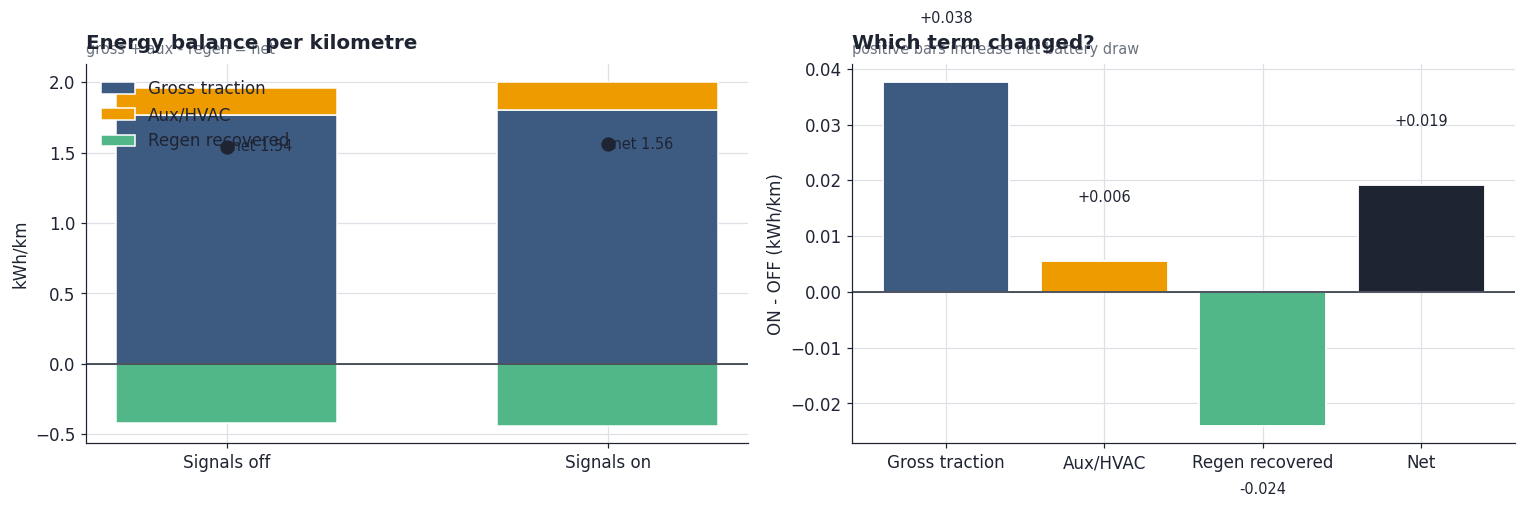

In [40]:
parts = summary[["gross_kWh", "aux_kWh", "regen_kWh", "net_kWh"]].copy()
parts_per_km = parts.div(summary["dist_km"], axis=0)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

ax = axes[0]
x = np.arange(2); width = 0.58; bottom = np.zeros(2)
for col, label, color in [("gross_kWh", "Gross traction", ACC), ("aux_kWh", "Aux/HVAC", ACC2)]:
    vals = parts_per_km.loc[["Signals off", "Signals on"], col].values
    ax.bar(x, vals, bottom=bottom, width=width, color=color, edgecolor="white", label=label)
    bottom += vals
regen = parts_per_km.loc[["Signals off", "Signals on"], "regen_kWh"].values
ax.bar(x, -regen, width=width, color=REGEN, edgecolor="white", label="Regen recovered")
net = parts_per_km.loc[["Signals off", "Signals on"], "net_kWh"].values
for xi, nv in zip(x, net):
    ax.scatter(xi, nv, s=70, color=INK, zorder=5)
    ax.text(xi, nv, f" net {nv:.2f}", ha="left", va="center", fontsize=9.5, color=INK)
ax.axhline(0, color=INK, lw=1)
ax.set_xticks(x); ax.set_xticklabels(["Signals off", "Signals on"])
ax.set_ylabel("kWh/km"); ax.legend(loc="upper left")
titled(ax, "Energy balance per kilometre", "gross + aux - regen = net")

ax = axes[1]
delta_parts = parts_per_km.loc["Signals on"] - parts_per_km.loc["Signals off"]
labels = ["Gross traction", "Aux/HVAC", "Regen recovered", "Net"]
vals = [delta_parts.gross_kWh, delta_parts.aux_kWh, -delta_parts.regen_kWh, delta_parts.net_kWh]
ax.bar(labels, vals, color=[ACC, ACC2, REGEN, INK], edgecolor="white", linewidth=1.2)
ax.axhline(0, color=INK, lw=1)
for i, v in enumerate(vals):
    ax.text(i, v + (0.01 if v >= 0 else -0.01), f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9.5)
ax.set_ylabel("ON - OFF (kWh/km)")
titled(ax, "Which term changed?", "positive bars increase net battery draw")
plt.tight_layout(); savefig(fig, "02_energy_balance_delta"); plt.show()


## 6. Trip-level paired comparison

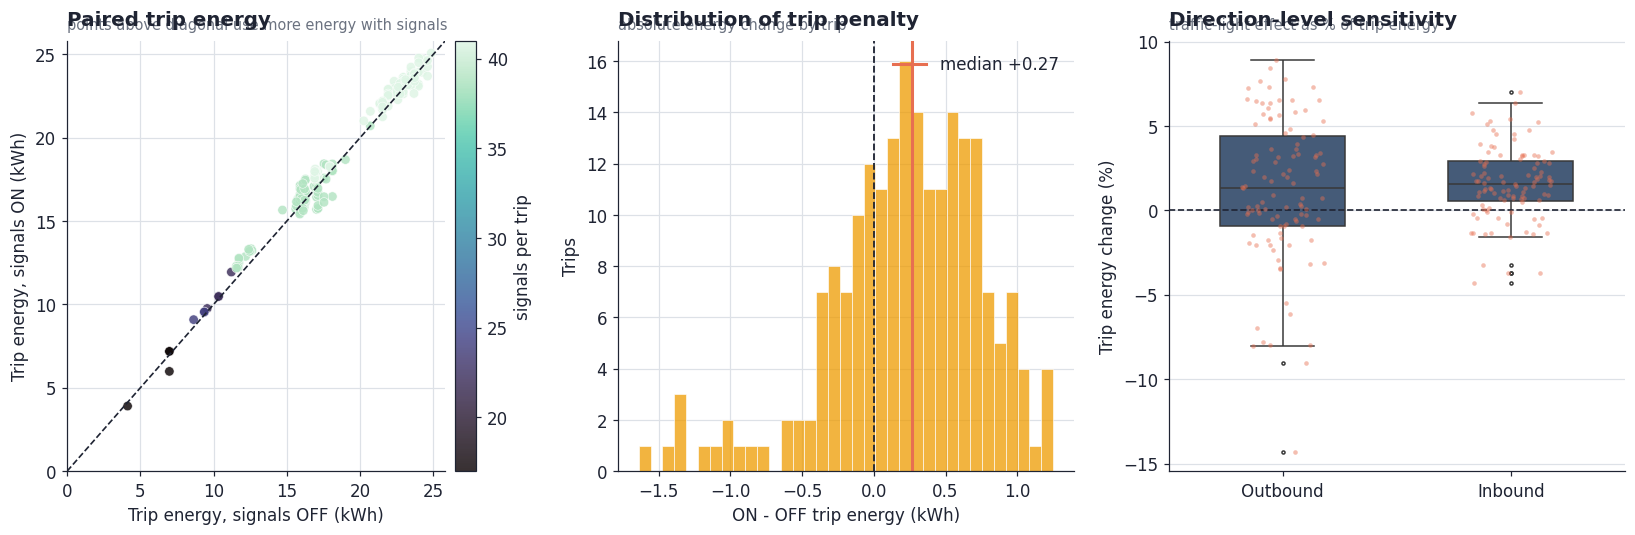

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
mx = max(trip_pair.net_kWh_off.max(), trip_pair.net_kWh_on.max()) * 1.03
sc0 = ax.scatter(trip_pair.net_kWh_off, trip_pair.net_kWh_on, c=trip_pair.n_signals_on,
                 cmap=SEQ, s=38, alpha=.82, edgecolor="white", linewidth=.4)
ax.plot([0, mx], [0, mx], color=INK, lw=1.1, ls="--")
ax.set_xlim(0, mx); ax.set_ylim(0, mx)
ax.set_xlabel("Trip energy, signals OFF (kWh)"); ax.set_ylabel("Trip energy, signals ON (kWh)")
titled(ax, "Paired trip energy", "points above diagonal use more energy with signals")
cb = plt.colorbar(sc0, ax=ax, pad=.02); cb.set_label("signals per trip")

ax = axes[1]
sns.histplot(trip_pair.delta_net_kWh, bins=35, color=ACC2, edgecolor="white", linewidth=.4, ax=ax)
ax.axvline(0, color=INK, lw=1.2, ls="--")
ax.axvline(trip_pair.delta_net_kWh.median(), color=ON, lw=2, label=f"median {trip_pair.delta_net_kWh.median():+.2f}")
ax.set_xlabel("ON - OFF trip energy (kWh)"); ax.set_ylabel("Trips"); ax.legend(loc="upper right")
titled(ax, "Distribution of trip penalty", "absolute energy change by trip")

ax = axes[2]
plot_df = trip_pair.assign(dir_label=trip_pair["dir_label_on"])
sns.boxplot(data=plot_df, x="dir_label", y="delta_pct_energy", color=ACC, width=.55, fliersize=2, linewidth=1, ax=ax)
sns.stripplot(data=plot_df, x="dir_label", y="delta_pct_energy", color=ON, size=3, alpha=.45, jitter=.18, ax=ax)
ax.axhline(0, color=INK, lw=1.1, ls="--")
ax.set_xlabel(""); ax.set_ylabel("Trip energy change (%)")
titled(ax, "Direction-level sensitivity", "traffic-light effect as % of trip energy")
plt.tight_layout(); savefig(fig, "03_trip_paired_comparison"); plt.show()


## 7. Time-of-day profile

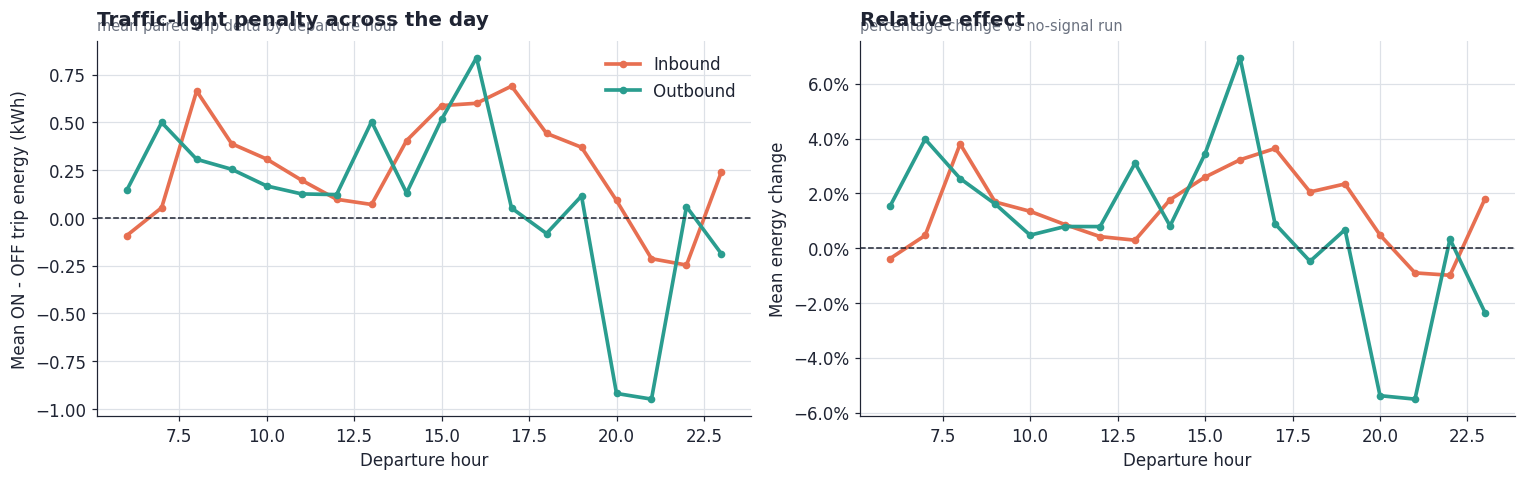

In [42]:
hourly = (trip_pair.assign(dir_label=trip_pair["dir_label_on"])
    .groupby(["dep_hour_on", "dir_label"], observed=True)
    .agg(delta_kWh=("delta_net_kWh", "mean"), delta_pct=("delta_pct_energy", "mean"),
         trips=("trip_id", "count"), signals=("n_signals_on", "mean"))
    .reset_index())
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)

ax = axes[0]
for dlab, g in hourly.groupby("dir_label", observed=True):
    c = OFF if dlab == "Outbound" else ON
    ax.plot(g.dep_hour_on, g.delta_kWh, color=c, lw=2.4, marker="o", ms=4, label=dlab)
ax.axhline(0, color=INK, lw=1, ls="--")
ax.set_xlabel("Departure hour"); ax.set_ylabel("Mean ON - OFF trip energy (kWh)"); ax.legend(title="")
titled(ax, "Traffic-light penalty across the day", "mean paired trip delta by departure hour")

ax = axes[1]
for dlab, g in hourly.groupby("dir_label", observed=True):
    c = OFF if dlab == "Outbound" else ON
    ax.plot(g.dep_hour_on, g.delta_pct, color=c, lw=2.4, marker="o", ms=4, label=dlab)
ax.axhline(0, color=INK, lw=1, ls="--")
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel("Departure hour"); ax.set_ylabel("Mean energy change")
titled(ax, "Relative effect", "percentage change vs no-signal run")
plt.tight_layout(); savefig(fig, "04_time_of_day_delta"); plt.show()


## 8. Segment-level spatial signature

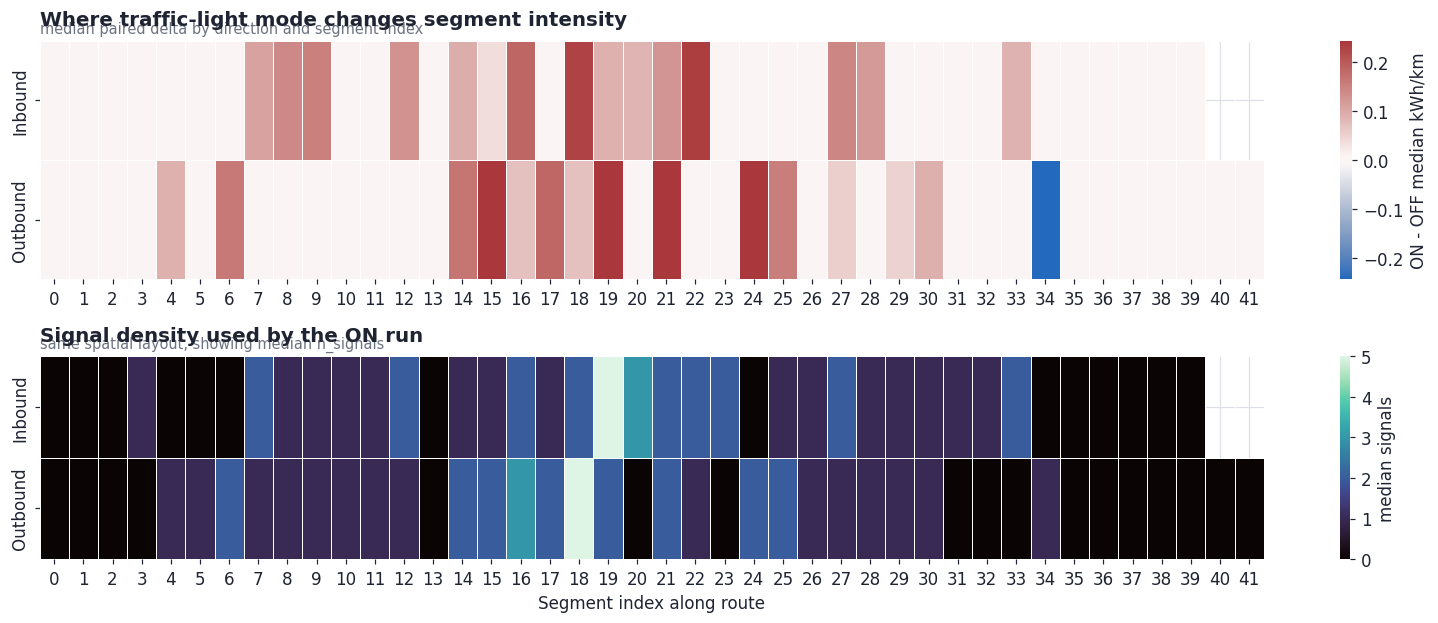

In [43]:
seg_profile = (seg_pair.assign(dir_label=seg_pair["dir_label_on"])
    .groupby(["dir_label", "segment"], observed=True)
    .agg(delta_kWh_km=("delta_net_battery_kWh_per_km", "median"),
         delta_kWh=("delta_net_battery_energy_kWh", "median"), signals=("n_signals_on", "median"), n=("trip_id", "count"))
    .reset_index())
heat = seg_profile.pivot(index="dir_label", columns="segment", values="delta_kWh_km")
sig_heat = seg_profile.pivot(index="dir_label", columns="segment", values="signals")

fig, axes = plt.subplots(2, 1, figsize=(14.5, 5.8), gridspec_kw={"height_ratios": [1.0, .85]})
ax = axes[0]
lim = np.nanpercentile(np.abs(heat.values), 95) if np.isfinite(heat.values).any() else 1
sns.heatmap(heat, cmap=DIV, center=0, vmin=-lim, vmax=lim, linewidths=.35, linecolor="white",
            cbar_kws={"label": "ON - OFF median kWh/km"}, ax=ax)
ax.set_xlabel(""); ax.set_ylabel("")
titled(ax, "Where traffic-light mode changes segment intensity", "median paired delta by direction and segment index")

ax = axes[1]
sns.heatmap(sig_heat, cmap=SEQ, linewidths=.35, linecolor="white", cbar_kws={"label": "median signals"}, ax=ax)
ax.set_xlabel("Segment index along route"); ax.set_ylabel("")
titled(ax, "Signal density used by the ON run", "same spatial layout, showing median n_signals")
plt.tight_layout(); savefig(fig, "05_segment_heatmaps"); plt.show()


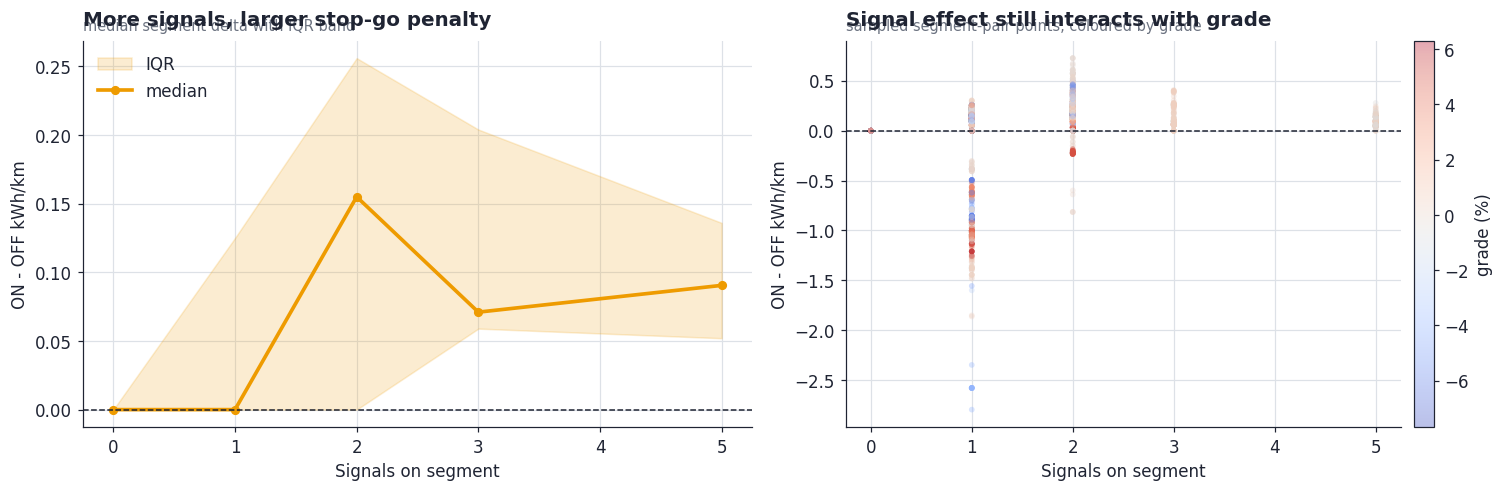

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
ax = axes[0]
seg_bins = (seg_pair.groupby("n_signals_on", observed=True)
    .agg(delta_kWh_km=("delta_net_battery_kWh_per_km", "median"),
         q1=("delta_net_battery_kWh_per_km", lambda s: s.quantile(.25)),
         q3=("delta_net_battery_kWh_per_km", lambda s: s.quantile(.75)), n=("trip_id", "count"))
    .reset_index())
ax.fill_between(seg_bins.n_signals_on, seg_bins.q1, seg_bins.q3, color=ACC2, alpha=.18, label="IQR")
ax.plot(seg_bins.n_signals_on, seg_bins.delta_kWh_km, color=ACC2, lw=2.4, marker="o", ms=5, label="median")
ax.axhline(0, color=INK, lw=1, ls="--")
ax.set_xlabel("Signals on segment"); ax.set_ylabel("ON - OFF kWh/km"); ax.legend(loc="upper left")
titled(ax, "More signals, larger stop-go penalty", "median segment delta with IQR band")

ax = axes[1]
sample = seg_pair.sample(min(len(seg_pair), 6000), random_state=7) if len(seg_pair) else seg_pair
sc = ax.scatter(sample.n_signals_on, sample.delta_net_battery_kWh_per_km, c=sample["grade_%_on"],
                cmap="coolwarm", s=14, alpha=.35, edgecolor="none")
ax.axhline(0, color=INK, lw=1, ls="--")
ax.set_xlabel("Signals on segment"); ax.set_ylabel("ON - OFF kWh/km")
cb = plt.colorbar(sc, ax=ax, pad=.02); cb.set_label("grade (%)")
titled(ax, "Signal effect still interacts with grade", "sampled segment-pair points, coloured by grade")
plt.tight_layout(); savefig(fig, "06_signal_count_vs_delta"); plt.show()


## 9. Duty-level operational impact

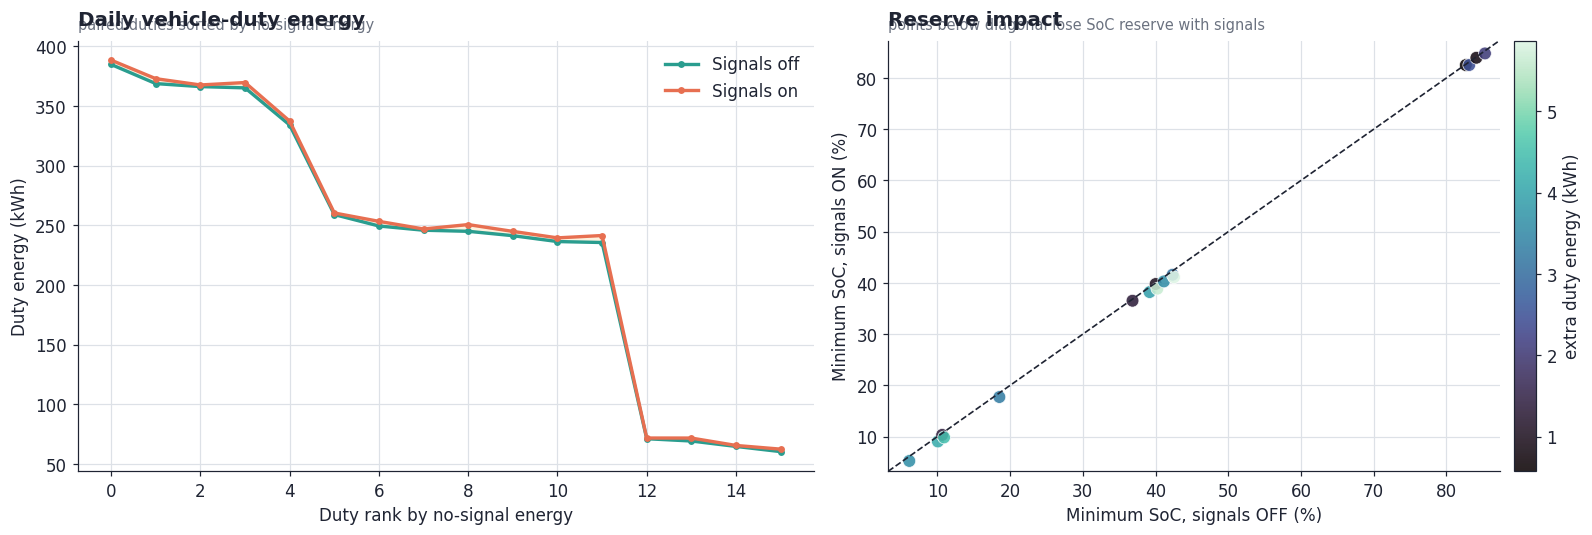

In [45]:
if duty_pair.empty:
    print("No paired duties found; skipping duty-level comparison.")
else:
    duty_plot = duty_pair.sort_values("net_kWh_off", ascending=False).reset_index(drop=True)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.0))
    ax = axes[0]
    x = np.arange(len(duty_plot))
    ax.plot(x, duty_plot.net_kWh_off, color=OFF, lw=2.2, marker="o", ms=3.5, label="Signals off")
    ax.plot(x, duty_plot.net_kWh_on, color=ON, lw=2.2, marker="o", ms=3.5, label="Signals on")
    ax.fill_between(x, duty_plot.net_kWh_off, duty_plot.net_kWh_on, color=ACC2, alpha=.13)
    ax.set_xlabel("Duty rank by no-signal energy"); ax.set_ylabel("Duty energy (kWh)"); ax.legend(loc="upper right")
    titled(ax, "Daily vehicle-duty energy", "paired duties sorted by no-signal energy")

    ax = axes[1]
    sc = ax.scatter(duty_plot.soc_min_off, duty_plot.soc_min_on, c=duty_plot.delta_net_kWh,
                    cmap=SEQ, s=70, alpha=.88, edgecolor="white", linewidth=.5)
    lo = min(duty_plot.soc_min_off.min(), duty_plot.soc_min_on.min()) - 2
    hi = max(duty_plot.soc_min_off.max(), duty_plot.soc_min_on.max()) + 2
    ax.plot([lo, hi], [lo, hi], color=INK, lw=1.1, ls="--")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("Minimum SoC, signals OFF (%)"); ax.set_ylabel("Minimum SoC, signals ON (%)")
    cb = plt.colorbar(sc, ax=ax, pad=.02); cb.set_label("extra duty energy (kWh)")
    titled(ax, "Reserve impact", "points below diagonal lose SoC reserve with signals")
    plt.tight_layout(); savefig(fig, "07_duty_operational_impact"); plt.show()


## 10. Largest affected trips and segments

In [46]:
trip_cols = ["trip_id", "duty_id_on", "dir_label_on", "trip_start_time_on", "dist_km_on", "n_signals_on",
             "net_kWh_off", "net_kWh_on", "delta_net_kWh", "delta_pct_energy"]
print("Trips with the largest extra energy from traffic-light mode")
display(trip_pair.sort_values("delta_net_kWh", ascending=False)[trip_cols].head(12).round(3))

seg_cols_out = ["trip_id", "segment", "dir_label_on", "dep_hour_on", "length_m_on", "grade_%_on", "passengers_on",
                "n_signals_on", "net_battery_energy_kWh_off", "net_battery_energy_kWh_on",
                "delta_net_battery_energy_kWh", "delta_net_battery_kWh_per_km"]
print("\nSegments with the largest extra energy from traffic-light mode")
display(seg_pair.sort_values("delta_net_battery_energy_kWh", ascending=False)[seg_cols_out].head(15).round(3))


Trips with the largest extra energy from traffic-light mode


,trip_id,duty_id_on,dir_label_on,trip_start_time_on,dist_km_on,n_signals_on,net_kWh_off,net_kWh_on,delta_net_kWh,delta_pct_energy
45,5695_41567,234:5695_7778208_42080201,Outbound,13:05:00,12.024,39,16.263,17.513,1.250,7.686
28,5695_41193,234:5695_7778208_42080204,Outbound,10:25:00,12.024,39,15.900,17.138,1.238,7.786
46,5695_41589,234:5695_7778208_42080205,Outbound,13:15:00,12.024,39,16.263,17.454,1.191,7.323
118,5695_43134,234:5695_7778208_42080205,Inbound,08:40:00,12.283,41,16.928,18.117,1.189,7.024
74,5695_42191,234:5695_7778208_42080203,Outbound,17:25:00,12.024,39,16.078,17.244,1.166,7.252
174,5695_44347,234:5695_7778208_42080207,Inbound,17:20:00,12.283,41,16.896,17.967,1.071,6.339
159,5695_44019,234:5695_7778208_42080212,Inbound,15:00:00,12.283,41,22.316,23.380,1.064,4.768
66,5695_42027,234:5695_7778208_42080210,Outbound,16:25:00,12.024,39,11.728,12.772,1.044,8.902
40,5695_41455,234:5695_7778208_42080204,Outbound,12:15:00,12.024,39,15.900,16.935,1.035,6.509
65,5695_42006,234:5695_7778208_42080207,Outbound,16:15:00,12.024,39,11.728,12.717,0.989,8.433



Segments with the largest extra energy from traffic-light mode


,trip_id,segment,dir_label_on,dep_hour_on,length_m_on,grade_%_on,passengers_on,n_signals_on,net_battery_energy_kWh_off,net_battery_energy_kWh_on,delta_net_battery_energy_kWh,delta_net_battery_kWh_per_km
2317,5695_41811,19,Outbound,14,398.2,-0.25,75,2,0.333,0.623,0.290,0.727
1031,5695_41567,19,Outbound,13,398.2,-0.25,75,2,0.333,0.623,0.290,0.727
6872,5695_41677,19,Outbound,13,398.2,-0.25,75,2,0.333,0.623,0.290,0.727
3688,5695_41589,19,Outbound,13,398.2,-0.25,75,2,0.333,0.623,0.290,0.727
4462,5695_41723,19,Outbound,14,398.2,-0.25,75,2,0.333,0.623,0.290,0.727
5496,5695_41254,19,Outbound,10,398.2,-0.25,60,2,0.319,0.594,0.275,0.689
457,5695_42191,24,Outbound,17,439.0,-0.23,73,2,0.403,0.675,0.272,0.620
881,5695_41046,19,Outbound,9,398.2,-0.25,54,2,0.314,0.582,0.268,0.673
5414,5695_40929,19,Outbound,8,398.2,-0.25,52,2,0.312,0.578,0.266,0.668
3693,5695_41589,24,Outbound,13,439.0,-0.23,66,2,0.395,0.660,0.265,0.604


## 11. Interpretation checklist

Use this section when deciding whether the traffic-light model is ready for validation:

1. Magnitude: is the total energy increase plausible relative to expected stop-go losses?
2. Spatial pattern: do high deltas appear on segments with known signals and crossings?
3. Direction pattern: does the delta look symmetric where signal exposure is symmetric?
4. Energy balance: is most of the change in gross traction rather than auxiliary energy?
5. SoC reserve: do any duties become infeasible only because traffic-light mode is enabled?

If the segment heatmap shows zero signal counts in known suburban crossing areas, refresh the signal cache after the updated `traffic_signals.py` fetch logic, then rerun this notebook.